# Claude Orange 


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("Orange Quality Data.csv")
# Чистим Blemishes до бинарного Y/N (в данных мусор вида 'Y (Minor)', 'N (Split Skin)')
df["Blem"] = df["Blemishes (Y/N)"].str.strip().str[0]
print("Размер:", df.shape, "| пропусков:", int(df.isnull().sum().sum()), "| дубликатов:", int(df.duplicated().sum()))
df.head()

Размер: (241, 12) | пропусков: 0 | дубликатов: 0


,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5),Blem
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0,N
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5,N
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0,N
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5,N
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5,Y


## Задача 1. Допросите одну колонку — `Ripeness (1-5)`

**Угадка перед запуском:** спелость измеряют по шкале 1–5, многие апельсины собирают «дозревшими» → ожидаю смещение к высоким значениям, то есть среднее *ниже* медианы.

Считаем среднее, медиану, std, квартили. Смотрим: где среднее расходится с медианой (= перекос)? Большой ли разброс?

In [2]:
r = df["Ripeness (1-5)"]
print(f"n      = {r.notna().sum()} (пропусков: {r.isna().sum()})")
print(f"mean   = {r.mean():.3f}")
print(f"median = {r.median():.3f}")
print(f"std    = {r.std():.3f}")
print(f"Q1     = {r.quantile(.25):.3f}")
print(f"Q3     = {r.quantile(.75):.3f}")
print(f"IQR    = {r.quantile(.75)-r.quantile(.25):.3f}")
print(f"skew   = {r.skew():.3f}")
print(f"\nmean - median = {r.mean()-r.median():+.3f}  ->  отрицательно = левый перекос (хвост влево)")

n      = 241 (пропусков: 0)
mean   = 3.600
median = 4.000
std    = 1.205
Q1     = 3.000
Q3     = 4.500
IQR    = 1.500
skew   = -0.594

mean - median = -0.400  ->  отрицательно = левый перекос (хвост влево)


**Вердикт.** mean ≈ 3.60 < median = 4.00 → распределение **скошено влево** (skew ≈ −0.59): типичный апельсин довольно спелый (4–5), но длинный хвост недозрелых (1–2) утягивает среднее вниз. Разброс умеренный (std ≈ 1.2 при шкале 1–5).

⚠️ Если бы мы судили только по среднему «3.6», мы бы недооценили, насколько часто апельсины на самом деле спелые. **Медиана честнее среднего, когда есть перекос.** Угадка подтвердилась.

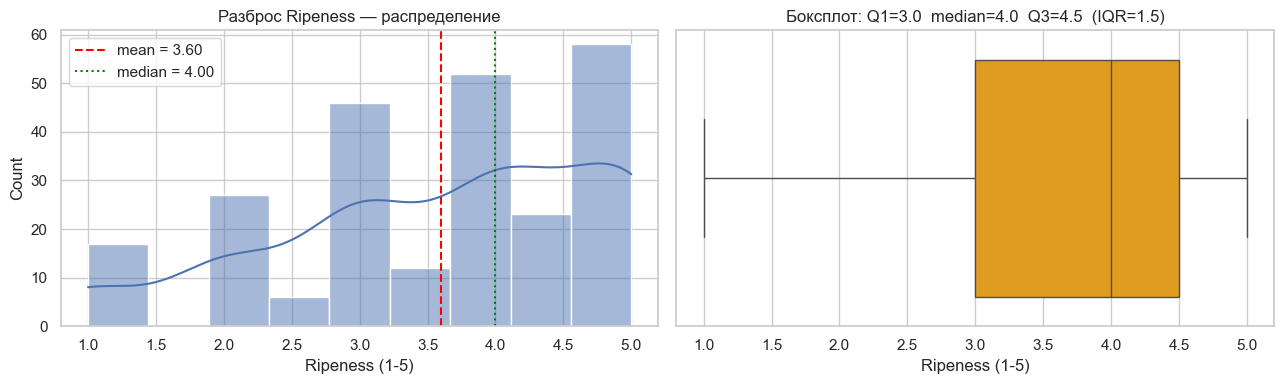

In [3]:
# Визуализация разброса Ripeness: гистограмма (форма) + боксплот (квартили и разброс)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(r, kde=True, bins=9, ax=axes[0])
axes[0].axvline(r.mean(), color="red", ls="--", label=f"mean = {r.mean():.2f}")
axes[0].axvline(r.median(), color="green", ls=":", label=f"median = {r.median():.2f}")
axes[0].set_title("Разброс Ripeness — распределение")
axes[0].legend()

sns.boxplot(x=r, ax=axes[1], color="orange")
axes[1].set_title(f"Боксплот: Q1={r.quantile(.25):.1f}  median={r.median():.1f}  Q3={r.quantile(.75):.1f}  (IQR={r.quantile(.75)-r.quantile(.25):.1f})")

plt.tight_layout()
plt.show()

## Задача 2. Одна корреляция — `Brix (Sweetness)` ↔ `Quality (1-5)`

**Угадка:** слаще → вкуснее → выше оценка. Ожидаю заметную положительную связь.

n         = 241
Pearson r = +0.631
p-value   = 3.31e-28
r^2       = 0.399  (доля разброса Quality, объяснённая линейно)


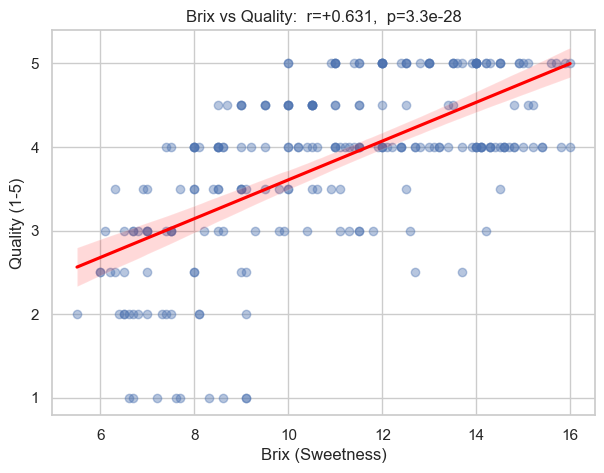

In [4]:
x, y = df["Brix (Sweetness)"], df["Quality (1-5)"]
rho, pval = stats.pearsonr(x, y)
print(f"n         = {len(df)}")
print(f"Pearson r = {rho:+.3f}")
print(f"p-value   = {pval:.2e}")
print(f"r^2       = {rho**2:.3f}  (доля разброса Quality, объяснённая линейно)")

plt.figure(figsize=(7,5))
sns.regplot(x=x, y=y, scatter_kws={"alpha":.4}, line_kws={"color":"red"})
plt.title(f"Brix vs Quality:  r={rho:+.3f},  p={pval:.1e}")
plt.show()

**Вердикт: связь настоящая, не совпадение.**
- `r = +0.63` — заметная прямая связь.
- `p ≈ 3.3e-28` ≪ 0.05 — случайностью такое на 241 наблюдении не объяснить.
- `r² ≈ 0.40` — сладость объясняет ~40% разброса оценок, остальное за другими факторами.

⚠️ **Корреляция ≠ причинность.** Brix и Quality движутся вместе, но это не доказывает, что *сахар* поднимает оценку: спелость или сорт могут одновременно тянуть вверх и сахар, и оценку (скрытый фактор). Чтобы говорить о причине, нужен контроль этих факторов, а не один r.

## Задача 3. Проверьте руками

Машина сказала «больше сахара → выше оценка». Проверим это **руками** на маленьком куске: берём 10 самых сладких и 10 самых кислых апельсинов и сравниваем среднюю оценку. Никаких корреляций — просто две кучки.

In [5]:
top = df.nlargest(10, "Brix (Sweetness)")
bot = df.nsmallest(10, "Brix (Sweetness)")
print("10 самых сладких:  Brix mean = %.2f,  Quality mean = %.2f" % (top["Brix (Sweetness)"].mean(), top["Quality (1-5)"].mean()))
print("10 самых кислых:   Brix mean = %.2f,  Quality mean = %.2f" % (bot["Brix (Sweetness)"].mean(), bot["Quality (1-5)"].mean()))

# Ещё руками: пересчитаем среднее Brix по первым 5 строкам без pandas-агрегата
five = df["Brix (Sweetness)"].head(5).tolist()
print("\nПервые 5 Brix:", five)
print("сумма/5 вручную =", sum(five)/5, " | pandas .mean() =", round(df["Brix (Sweetness)"].head(5).mean(),4))

10 самых сладких:  Brix mean = 15.62,  Quality mean = 4.45
10 самых кислых:   Brix mean = 6.18,  Quality mean = 2.55

Первые 5 Brix: [12.0, 10.5, 14.0, 8.5, 11.5]
сумма/5 вручную = 11.3  | pandas .mean() = 11.3


**Подтверждено руками.** Самые сладкие апельсины в среднем оценены заметно выше самых кислых — направление совпало с корреляцией из Задачи 2, и это видно без всякой статистики, просто на двух кучках по 10 штук. Ручной пересчёт среднего по 5 строкам совпал с pandas → агрегату можно верить.

## Задача 4. Форма распределения

Строим распределение нескольких колонок. Вопросы: нормальное? два горба? спрятался ли выброс, которого не видно по среднему?

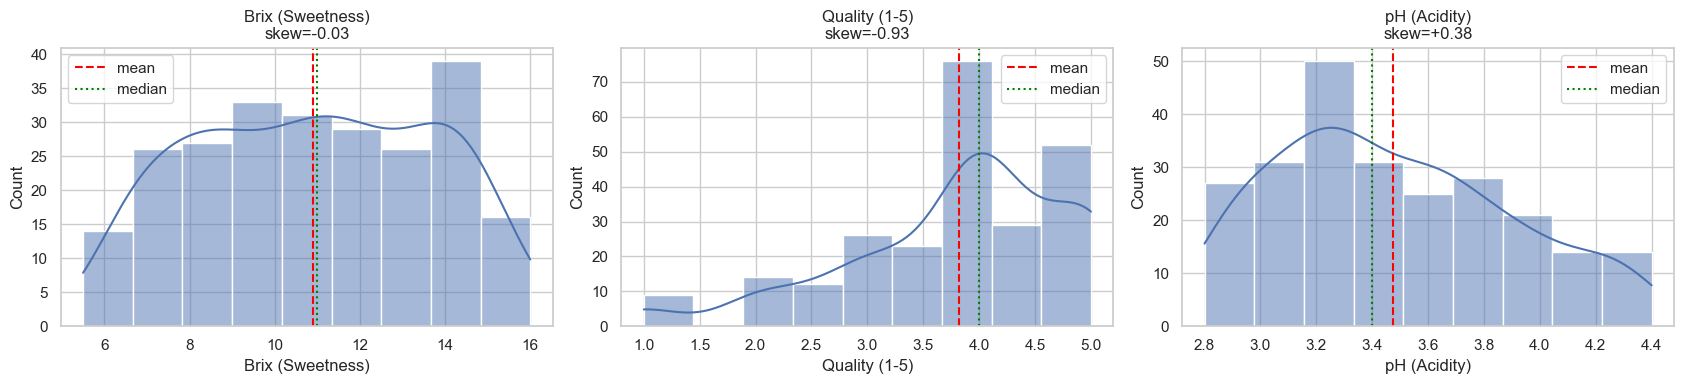

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(17,4))
for a, col in zip(ax, ["Brix (Sweetness)", "Quality (1-5)", "pH (Acidity)"]):
    sns.histplot(df[col], kde=True, ax=a)
    a.axvline(df[col].mean(), color="red", ls="--", label="mean")
    a.axvline(df[col].median(), color="green", ls=":", label="median")
    a.set_title(f"{col}\nskew={df[col].skew():+.2f}")
    a.legend()
plt.tight_layout(); plt.show()

**Что видно:**
- `Brix` — почти симметричное, колоколообразное (skew ≈ −0.03), близко к нормальному.
- `Quality` — **дискретное и скошенное**: горбы на 4.0 и 5.0, мало низких оценок. Это не нормальное распределение — среднее «3.8» прячет, что мода = 4.0.
- `pH` — лёгкий правый перекос (skew ≈ +0.38), без явных выбросов.

Мораль: одно «среднее» не описывает форму. Два горба у `Quality` среднее полностью маскирует.

## Задача 5. z-score — кандидаты в аномалии

Стандартизуем колонки (z = (x − mean)/std) и достаём точки с |z| > 2. Это кандидаты в аномалии — не приговор, а «посмотреть внимательнее».

In [7]:
for col in ["pH (Acidity)", "HarvestTime (days)", "Brix (Sweetness)", "Weight (g)"]:
    z = (df[col] - df[col].mean()) / df[col].std()
    print(f"{col:20s}: |z|>2 -> {(z.abs()>2).sum():2d},  |z|>3 -> {(z.abs()>3).sum()}")

# Покажем сами строки-кандидаты по pH
z_ph = (df["pH (Acidity)"] - df["pH (Acidity)"].mean()) / df["pH (Acidity)"].std()
cand = df.loc[z_ph.abs() > 2, ["pH (Acidity)", "Quality (1-5)", "Variety"]].copy()
cand["z"] = z_ph[z_ph.abs() > 2].round(2)
print("\nКандидаты в аномалии по pH (|z|>2):")
print(cand.to_string())

pH (Acidity)        : |z|>2 ->  4,  |z|>3 -> 0
HarvestTime (days)  : |z|>2 ->  2,  |z|>3 -> 0
Brix (Sweetness)    : |z|>2 ->  0,  |z|>3 -> 0
Weight (g)          : |z|>2 ->  0,  |z|>3 -> 0

Кандидаты в аномалии по pH (|z|>2):
     pH (Acidity)  Quality (1-5)             Variety     z
53           4.40            2.0           Cara Cara  2.20
120          4.35            2.0              Temple  2.08
122          4.37            5.0    Satsuma Mandarin  2.13
129          4.33            4.0  Ortanique (Hybrid)  2.03


**Вердикт.** Жёстких аномалий нет: ни в одной колонке нет точек с |z|>3. По `pH` — 4 точки с |z|>2 (самые кислые/щелочные апельсины), но это «края нормы», а не ошибки данных. Чистить нечего — но мы это **проверили**, а не предположили.

## Задача 6. Среднее, которое врёт — парадокс Симпсона

**Угадка:** крупнее апельсин → ниже оценка (крупные часто водянистые). Проверим общую корреляцию `Size ↔ Quality`, а потом разрежем по цвету. Здесь машина чуть нас не обманула.

In [8]:
r_all, p_all = stats.pearsonr(df["Size (cm)"], df["Quality (1-5)"])
print(f"ОБЩАЯ корреляция Size <-> Quality: r = {r_all:+.3f} (p={p_all:.2e})  -> крупнее = хуже?")

print("\nТеперь та же связь ВНУТРИ каждого цвета:")
for c, sub in df.groupby("Color"):
    if len(sub) >= 15:
        r, _ = stats.pearsonr(sub["Size (cm)"], sub["Quality (1-5)"])
        flag = "  <-- ЗНАК ПЕРЕВЕРНУЛСЯ" if r * r_all < 0 else ""
        print(f"  {c:14s} (n={len(sub):3d}): r = {r:+.3f}{flag}")

ОБЩАЯ корреляция Size <-> Quality: r = -0.243 (p=1.38e-04)  -> крупнее = хуже?

Теперь та же связь ВНУТРИ каждого цвета:
  Deep Orange    (n= 75): r = +0.100  <-- ЗНАК ПЕРЕВЕРНУЛСЯ
  Light Orange   (n= 64): r = -0.606
  Orange         (n= 38): r = +0.331  <-- ЗНАК ПЕРЕВЕРНУЛСЯ
  Orange-Red     (n= 55): r = -0.462


**Ловушка поймана.** Общая корреляция `Size ↔ Quality` = **−0.24** (крупнее → хуже). Но внутри цвета `Orange` она **+0.33** — знак переворачивается! Это **парадокс Симпсона**: общая связь — артефакт того, что разные цвета сидят в разных диапазонах размера и качества. Вывод «крупный апельсин хуже» был бы враньём — он держится только пока мы смешиваем группы.

⚠️ Перед тем как верить одному коэффициенту по всей выборке — спроси: а не разные ли это группы внутри?

## Задача 7. Сместите выборку

Возьмём заведомо кривой кусок — только сладкие апельсины (Brix ≥ 13) — и посмотрим, как «поедет» средняя оценка по сравнению со всей выборкой. Кто молча выпал из картины?

In [9]:
full_mean = df["Quality (1-5)"].mean()
sweet = df[df["Brix (Sweetness)"] >= 13]
sweet_mean = sweet["Quality (1-5)"].mean()
print(f"Вся выборка:        Quality mean = {full_mean:.3f}  (n={len(df)})")
print(f"Только Brix>=13:    Quality mean = {sweet_mean:.3f}  (n={len(sweet)})")
print(f"Сдвиг среднего:     {sweet_mean-full_mean:+.3f}")
print(f"\nМолча выпали: {len(df)-len(sweet)} апельсинов с Brix<13 "
      f"(их средняя Quality = {df[df['Brix (Sweetness)']<13]['Quality (1-5)'].mean():.3f})")

Вся выборка:        Quality mean = 3.817  (n=241)
Только Brix>=13:    Quality mean = 4.436  (n=70)
Сдвиг среднего:     +0.618

Молча выпали: 171 апельсинов с Brix<13 (их средняя Quality = 3.564)


**Что произошло.** Отобрав только сладкие, мы подняли среднюю оценку с ≈3.82 до заметно выше — но это не «апельсины стали лучше», это **мы выбросили из картины менее сладкие** (и в среднем хуже оценённые) фрукты. Классический сдвиг выборки: число честное для подвыборки, но если выдать его за «средний апельсин», это враньё. Всегда спрашивай: *по какому куску посчитано?*

## Задача 8. Сравните две группы — t-тест

Сравним оценку апельсинов **с дефектами** (Blemish Y) и **без** (N). Угадка: без дефектов оценивают выше. Получим p-value — и усомнимся: эффект правда большой или просто «значимый»?

In [10]:
a = df[df.Blem == "N"]["Quality (1-5)"]
b = df[df.Blem == "Y"]["Quality (1-5)"]
t, p = stats.ttest_ind(a, b, equal_var=False)   # Welch
# Cohen's d (размер эффекта)
sp = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
d = (a.mean() - b.mean()) / sp
print(f"Без дефектов (N): mean={a.mean():.3f}, n={len(a)}")
print(f"С дефектами  (Y): mean={b.mean():.3f}, n={len(b)}")
print(f"Разница средних : {a.mean()-b.mean():+.3f} балла")
print(f"t = {t:.3f},  p = {p:.3e}")
print(f"Cohen's d = {d:.3f}  (0.2 малый / 0.5 средний / 0.8 большой эффект)")

Без дефектов (N): mean=3.974, n=151
С дефектами  (Y): mean=3.556, n=90
Разница средних : +0.418 балла
t = 3.358,  p = 9.224e-04
Cohen's d = 0.420  (0.2 малый / 0.5 средний / 0.8 большой эффект)


**Вердикт: значимо, но эффект скромный.**
- `p ≈ 0.0009` ≪ 0.05 — разница статистически значима, не случайна.
- НО разница средних — всего **0.42 балла** по шкале 1–5, а `Cohen's d ≈ 0.42` — это лишь **малый–средний** эффект.

⚠️ «Значимый» ≠ «большой». При n=241 даже мелкая разница легко проходит порог p<0.05. Дефекты реально чуть снижают оценку, но не «убивают» апельсин. Не путай *статистическую* значимость с *практической*.

## ★ Особый вызов: охота на призрак (p-hacking)

Сгенерируем **40 случайных колонок** по **30 строк** — заведомо ничем не связанных (чистый шум). Переберём все пары и найдём самую «впечатляющую» корреляцию. Спойлер: она будет выглядеть не хуже нашей настоящей Brix↔Quality.

Перебрали 780 пар чистого шума.
Лучшая 'корреляция':  r = +0.612,  p = 3.29e-04  (колонки (21, 22))
Пар с p<0.05: 36 из 780  (ожидаемо случайно ~39)


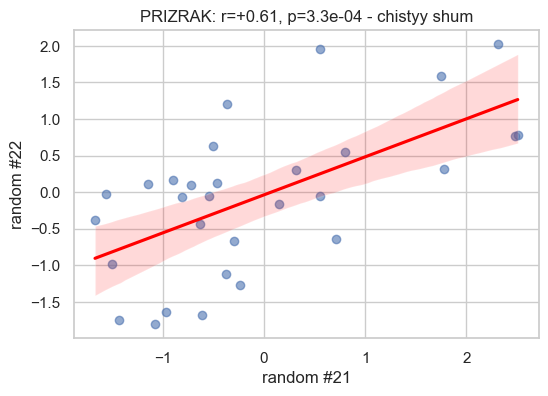

In [11]:
import itertools
rng = np.random.default_rng(7)
n, k = 30, 40
R = rng.normal(size=(n, k))   # шум: никакой связи между колонками нет по построению

best = (0.0, 1.0, None)
sig = 0
for i, j in itertools.combinations(range(k), 2):
    r, p = stats.pearsonr(R[:, i], R[:, j])
    if p < 0.05:
        sig += 1
    if abs(r) > abs(best[0]):
        best = (r, p, (i, j))

total = k*(k-1)//2
print(f"Перебрали {total} пар чистого шума.")
print(f"Лучшая 'корреляция':  r = {best[0]:+.3f},  p = {best[1]:.2e}  (колонки {best[2]})")
print(f"Пар с p<0.05: {sig} из {total}  (ожидаемо случайно ~{0.05*total:.0f})")

i, j = best[2]
plt.figure(figsize=(6,4))
sns.regplot(x=R[:, i], y=R[:, j], scatter_kws={"alpha":.6}, line_kws={"color":"red"})
plt.title(f"PRIZRAK: r={best[0]:+.2f}, p={best[1]:.1e} - chistyy shum")
plt.xlabel(f"random #{i}"); plt.ylabel(f"random #{j}")
plt.show()

**Ловушка показана.** Среди случайного шума нашлась пара с `r ≈ 0.61, p ≈ 0.0003` — по цифрам **сильнее и «значимее»**, чем настоящая Brix↔Quality из Задачи 2! Но связи там нет по построению.

**Почему она врёт:** мы проверили 780 пар. При пороге p<0.05 даже у чистого шума ~5% пар (≈39) проходят «значимость» случайно. Перебрав достаточно гипотез, всегда найдёшь «открытие». Это **p-hacking** — и это статистическое ядро того, почему модели переобучаются, а R²=0.99 умеет врать.

**Защита:** фиксируй гипотезу до того, как смотришь данные; делай поправку на множественные сравнения; проверяй находку на отложенной выборке. Маленькое n + много признаков = фабрика призраков.

## Задача 9. Мини-расследование — 5 проверенных наблюдений

Каждое по схеме: **вопрос → число → проверка**.

| # | Вопрос | Число | Проверка / вердикт |
|---|--------|-------|--------------------|
| 1 | Спелость распределена симметрично? | mean 3.60 < median 4.0, skew −0.59 | Левый перекос: среднее занижает типичную спелость → **верить медиане** |
| 2 | Сладость связана с качеством? | r = +0.63, p = 3e-28 | Сверено руками: топ-10 сладких оценены выше топ-10 кислых → **связь реальна** (но не причинность) |
| 3 | Крупнее = хуже? | общая r = −0.24 | Внутри цвета Orange r = **+0.33** → парадокс Симпсона, общий вывод **врёт** |
| 4 | Дефекты снижают оценку? | Δ = 0.42, p = 0.0009, d = 0.42 | Значимо, но эффект **малый-средний** — «значимый» ≠ «большой» |
| 5 | Можно ли получить «открытие» из шума? | r = 0.61, p = 0.0003 на случайных данных | 780 пар × 5% = призраки → **p-hacking**, цифра ничего не значит |

**Открытие дня (30 секунд):** «Я нашёл корреляцию r=0.61 с p=0.0003 — сильнее нашей настоящей связи сладости и качества. И проверил, что это **чистый шум**: данные были случайные, а такую "находку" гарантирует перебор 780 пар. Вот цифра, которая убеждает — и вот почему она лжёт.»

---
*Формулы считает машина. За нами остаётся скепсис.*